# **FINAL PROJECT:**
# **PROJECT:1 "PORTFOLIO PROJECT WALKTHROUGHT (KAGGLE : TITANIC-DATASET)"**

**"The goal of this project is to create a machine learning model to forecast passenger survival by analyzing the Titanic dataset. It comprises feature engineering, model evaluation, data cleansing, and exploratory data analysis."**

# **"Import Libraries"**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# **"Load Dataset"**

In [2]:
df = pd.read_csv("train.csv")
df_label=df.copy()
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
df.tail()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.00,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.00,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.45,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.00,C148,C
890,891,0,3,"Dooley, Mr. Patrick",male,32.0,0,0,370376,7.75,NaN,Q


# **"Data Overview (Data Understanding)"**

In [4]:
print("DATA SHAPE")
df.shape

DATA SHAPE


(891, 12)

In [5]:
print("DATA COLUMNS")
df.columns

DATA COLUMNS


Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [6]:
print("DATA INFORMATION")
df.info()

DATA INFORMATION
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [7]:
print("DESCRIPTIVE STATISTIC SUMMERY")
df.describe()

DESCRIPTIVE STATISTIC SUMMERY


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [8]:
df.nunique()

PassengerId    891
Survived         2
Pclass           3
Name           891
Sex              2
Age             88
SibSp            7
Parch            7
Ticket         681
Fare           248
Cabin          147
Embarked         3
dtype: int64

In [224]:
print(df["Sex"].unique())
print(df["Pclass"].unique())
print(df["SibSp"].unique())

['male' 'female']
[3 1 2]
[1 0 3 4 2 5 8]


**Afer overviwed the data it is understand that, this data contains 891 rows and 12 columns, the RangeIndex: 891 entries, 0 to 890 and has the following data types like: float64(2), int64(5), object(5)**

# **"Data Cleaning"**

**"Check Misssing Values"**

In [9]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

**"Drop Duplicate Values"**

In [10]:
df.drop_duplicates(inplace=True)
print(df)

     PassengerId  Survived  Pclass  \
0              1         0       3   
1              2         1       1   
2              3         1       3   
3              4         1       1   
4              5         0       3   
..           ...       ...     ...   
886          887         0       2   
887          888         1       1   
888          889         0       3   
889          890         1       1   
890          891         0       3   

                                                  Name     Sex   Age  SibSp  \
0                              Braund, Mr. Owen Harris    male  22.0      1   
1    Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                               Heikkinen, Miss. Laina  female  26.0      0   
3         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                             Allen, Mr. William Henry    male  35.0      0   
..                                                 ...     ...   ... 

**"Drop Unnecessary Columns (PassengerId, Name, Ticket, Cabin)"**

In [11]:
df.drop(columns=["PassengerId","Name","Ticket","Cabin"], inplace=True)
print(df)

     Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0           0       3    male  22.0      1      0   7.2500        S
1           1       1  female  38.0      1      0  71.2833        C
2           1       3  female  26.0      0      0   7.9250        S
3           1       1  female  35.0      1      0  53.1000        S
4           0       3    male  35.0      0      0   8.0500        S
..        ...     ...     ...   ...    ...    ...      ...      ...
886         0       2    male  27.0      0      0  13.0000        S
887         1       1  female  19.0      0      0  30.0000        S
888         0       3  female   NaN      1      2  23.4500        S
889         1       1    male  26.0      0      0  30.0000        C
890         0       3    male  32.0      0      0   7.7500        Q

[891 rows x 8 columns]


# **"Handling Missing Vlues"**  
Missing values handling (Age → median, Embarked → mode)

In [13]:
df["Age"].fillna(df["Age"].median(),inplace=True)
print(df)

     Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0           0       3    male  22.0      1      0   7.2500        S
1           1       1  female  38.0      1      0  71.2833        C
2           1       3  female  26.0      0      0   7.9250        S
3           1       1  female  35.0      1      0  53.1000        S
4           0       3    male  35.0      0      0   8.0500        S
..        ...     ...     ...   ...    ...    ...      ...      ...
886         0       2    male  27.0      0      0  13.0000        S
887         1       1  female  19.0      0      0  30.0000        S
888         0       3  female  28.0      1      2  23.4500        S
889         1       1    male  26.0      0      0  30.0000        C
890         0       3    male  32.0      0      0   7.7500        Q

[891 rows x 8 columns]


C:\Users\Aaqeeb Mushtaq\AppData\Local\Temp\ipykernel_2712\266594044.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Age"].fillna(df["Age"].median(),inplace=True)


In [14]:
df["Embarked"].fillna(df["Embarked"].mode()[0],inplace=True)
print(df)

     Survived  Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0           0       3    male  22.0      1      0   7.2500        S
1           1       1  female  38.0      1      0  71.2833        C
2           1       3  female  26.0      0      0   7.9250        S
3           1       1  female  35.0      1      0  53.1000        S
4           0       3    male  35.0      0      0   8.0500        S
..        ...     ...     ...   ...    ...    ...      ...      ...
886         0       2    male  27.0      0      0  13.0000        S
887         1       1  female  19.0      0      0  30.0000        S
888         0       3  female  28.0      1      2  23.4500        S
889         1       1    male  26.0      0      0  30.0000        C
890         0       3    male  32.0      0      0   7.7500        Q

[891 rows x 8 columns]


C:\Users\Aaqeeb Mushtaq\AppData\Local\Temp\ipykernel_2712\1013786003.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Embarked"].fillna(df["Embarked"].mode()[0],inplace=True)


**Missing values were handled to improve data quality and model performance.**

In [15]:
df.isnull().sum()

Survived    0
Pclass      0
Sex         0
Age         0
SibSp       0
Parch       0
Fare        0
Embarked    0
dtype: int64

**In this step we have checked the no of missing values in each columns by using (isnull().sum()).**
**after checking,it has analyzed that, these following columnss have missing values(Age, Cabin,Embarked).it is also analyzed that in cabin column has too many missing valued and it is useless for menaingfull analysis that's why it is dropped.also some other useless columns have been drop i,e (PassengerId,Name,Ticket) because it has no work in "EDA"Mssing values in (Age and Embarked) columns have been handled by using median and mode.**
**There are categorical values In "Embarked" column that's why "Mode" is used to filled it.**

# **"Exploratory Data Analysis (EDA)"**

# **"Data Visulization"**

**"CORRELATION MATRIX"**

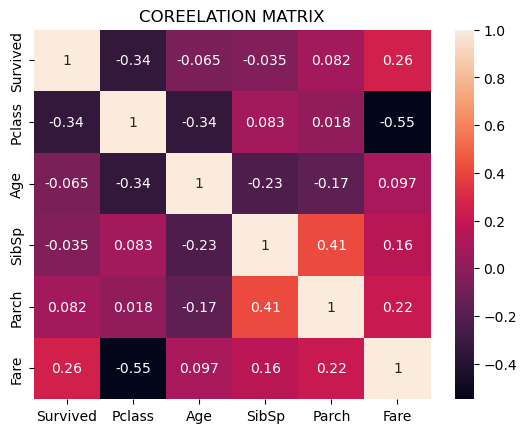

In [16]:
corr =df.corr(numeric_only=True)
sns.heatmap(corr, annot = True)
plt.title("COREELATION MATRIX")
plt.show()

**"The heatmap indicates that passenger class and fare significantly affect survival, while age and family features have weak influence. Family-related variables show moderate correlation.”**

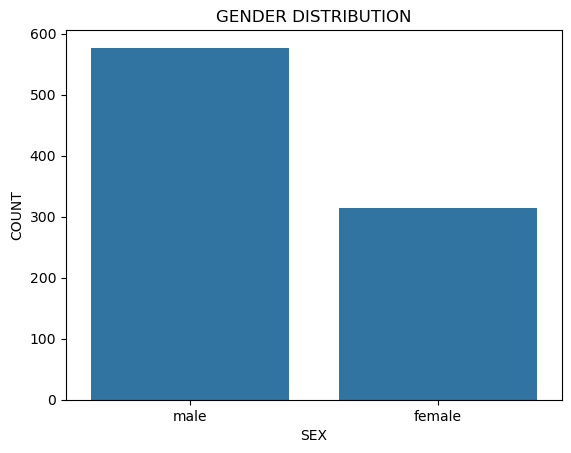

In [17]:
sns.countplot(x="Sex",data=df)
plt.title("GENDER DISTRIBUTION")
plt.xlabel("SEX")
plt.ylabel("COUNT")
plt.show()

**"The above countplot shows that the majority of the passengers were male and there were less female as compare to male in the ship."**

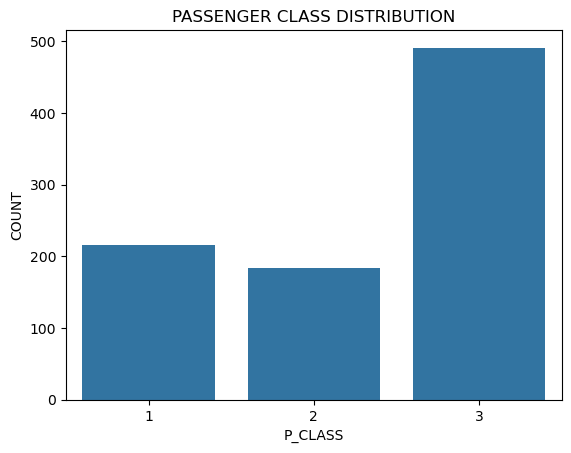

In [18]:
sns.countplot(x="Pclass",data=df)
plt.title("PASSENGER CLASS DISTRIBUTION")
plt.xlabel("P_CLASS")
plt.ylabel("COUNT")
plt.show()

**"The above graph of passenger distribution shows that most of the passenger belongs to 3rd class,fewer wer in 1st class and least in 2nd class."**

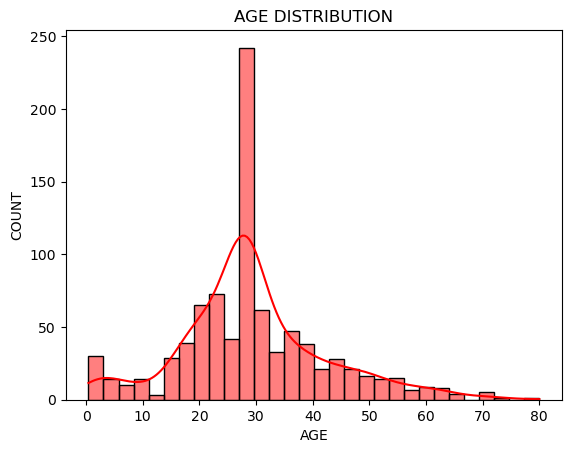

In [20]:
sns.histplot(df['Age'], kde=True, color='red')
plt.title("AGE DISTRIBUTION")
plt.xlabel("AGE")
plt.ylabel("COUNT")
plt.show()

**"The above graph shows that most of the passengers in the ship were between 20 and 40."**

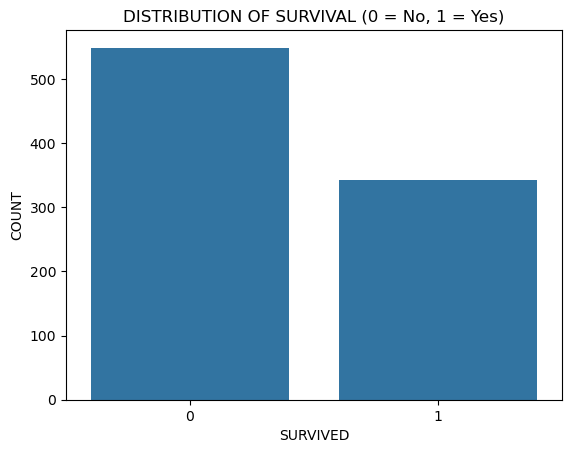

In [21]:
sns.countplot(x="Survived",data=df)
plt.title("DISTRIBUTION OF SURVIVAL (0 = No, 1 = Yes)")
plt.xlabel("SURVIVED")
plt.ylabel("COUNT")
plt.show()

**"The distribution of survival graph has Two bars on the x-axis:"0" (passengers who did not survive) and "1" (passengers who survived).
it is show that there were the high rang people who didn't survived in the ship."**

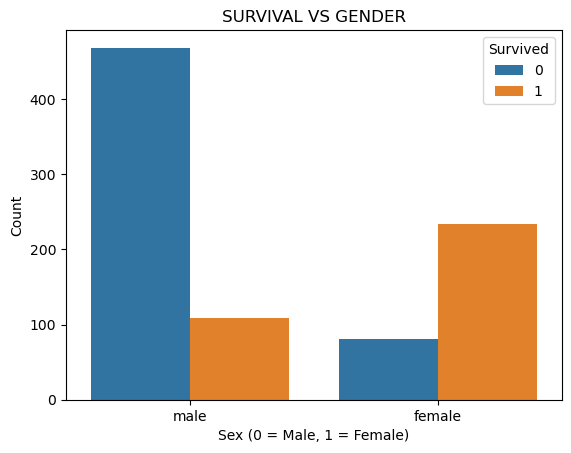

In [22]:
sns.countplot(x="Sex", hue="Survived",data=df)
plt.title("SURVIVAL VS GENDER")
plt.xlabel('Sex (0 = Male, 1 = Female)')
plt.ylabel('Count')
plt.show()

**This survival vs gender graph shows that female had a higher rate of survival as compared to male."**

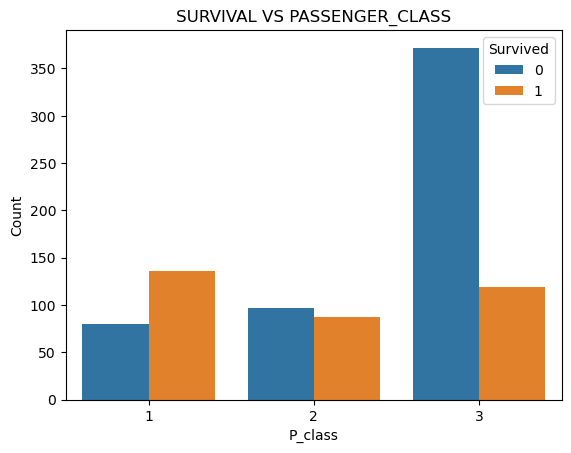

In [23]:
sns.countplot(x="Pclass",hue="Survived",data=df)
plt.title("SURVIVAL VS PASSENGER_CLASS")
plt.xlabel('P_class')
plt.ylabel('Count')
plt.show()

**The above survival vs passenger class graph shows that the passenger in the 3rd class had higher rate who didn't survived as compared to 1st and 2nd class."** 

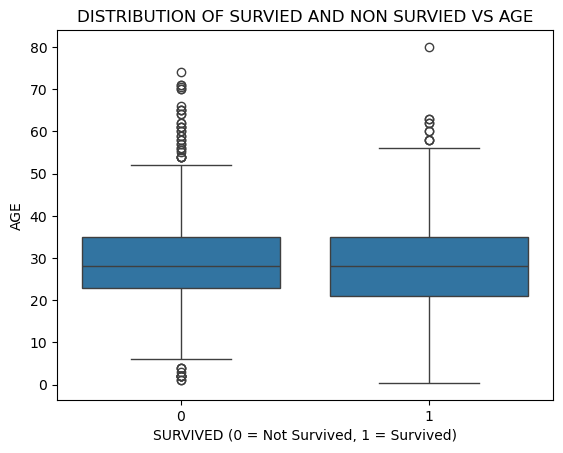

In [24]:
sns.boxplot(x="Survived",y="Age",data=df)
plt.title("DISTRIBUTION OF SURVIED AND NON SURVIED VS AGE")
plt.xlabel("SURVIVED (0 = Not Survived, 1 = Survived)")
plt.ylabel("AGE")
plt.show()

**The boxplot shows that the age distribution of survivors and non-survivors is quite similar.The median age is almost the same, indicating that age did not significantly impact survival.”**


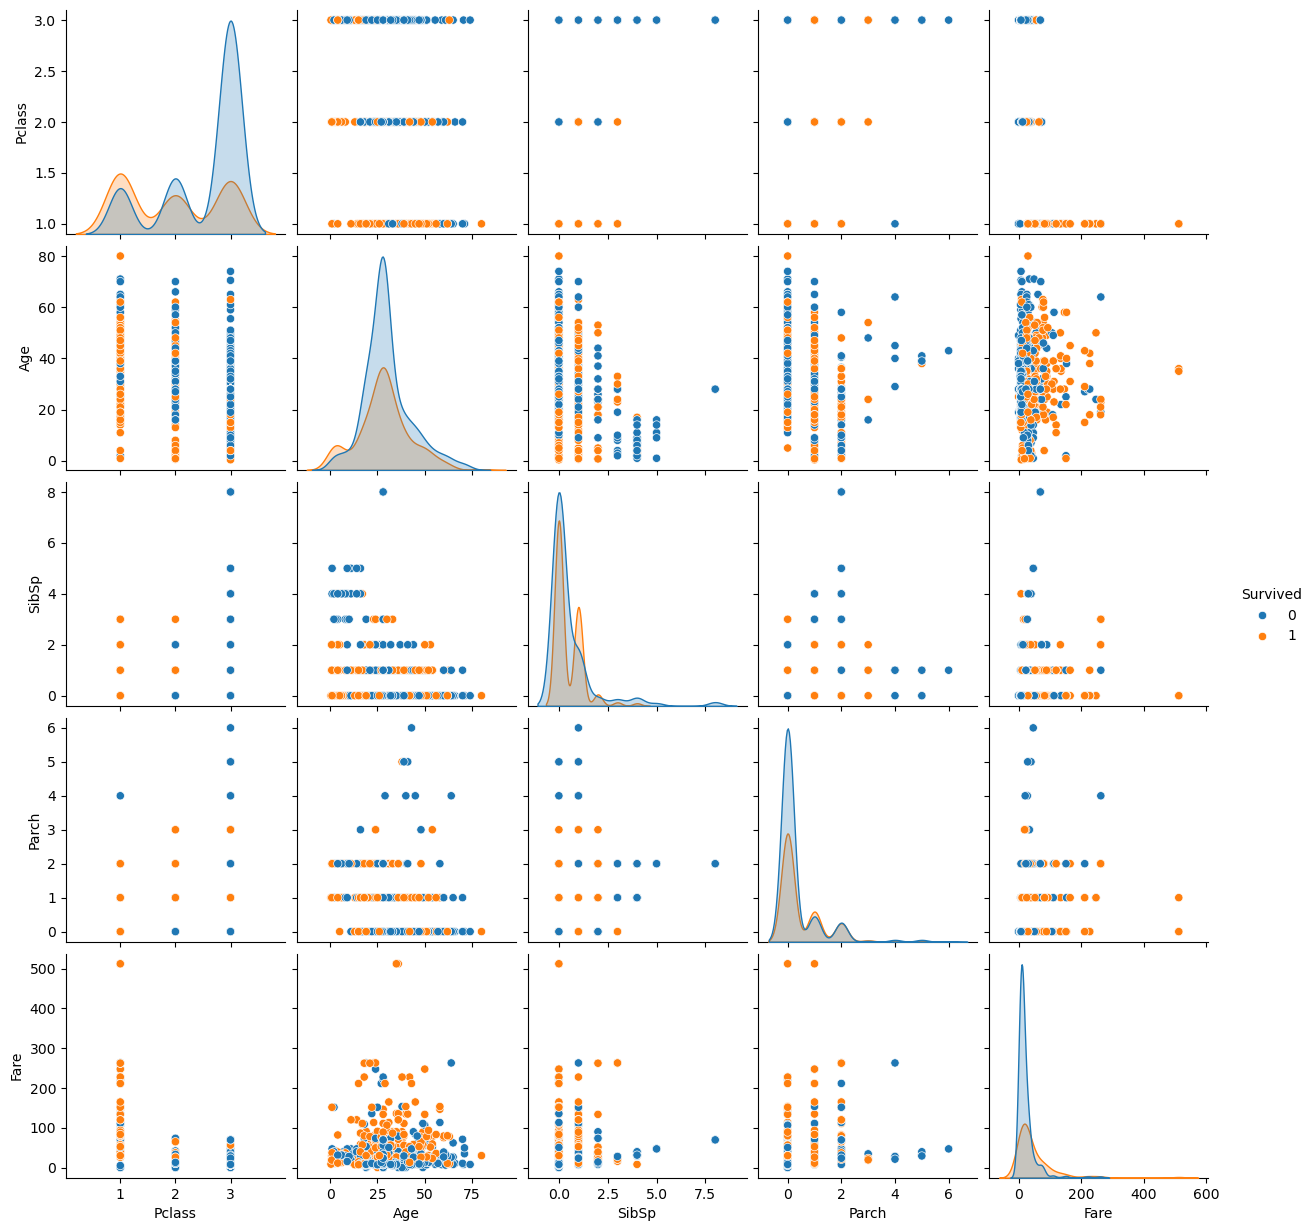

In [25]:
sns.pairplot(df,hue='Survived')
plt.show()

**"The about pair plot graph of survival indicates that,Blue points (0) = Not Survived, orange(1) = Survived.Young passengers and children had higher survival rate.High fare (1st class) passengers mostly survived.Large families had lower survival."**

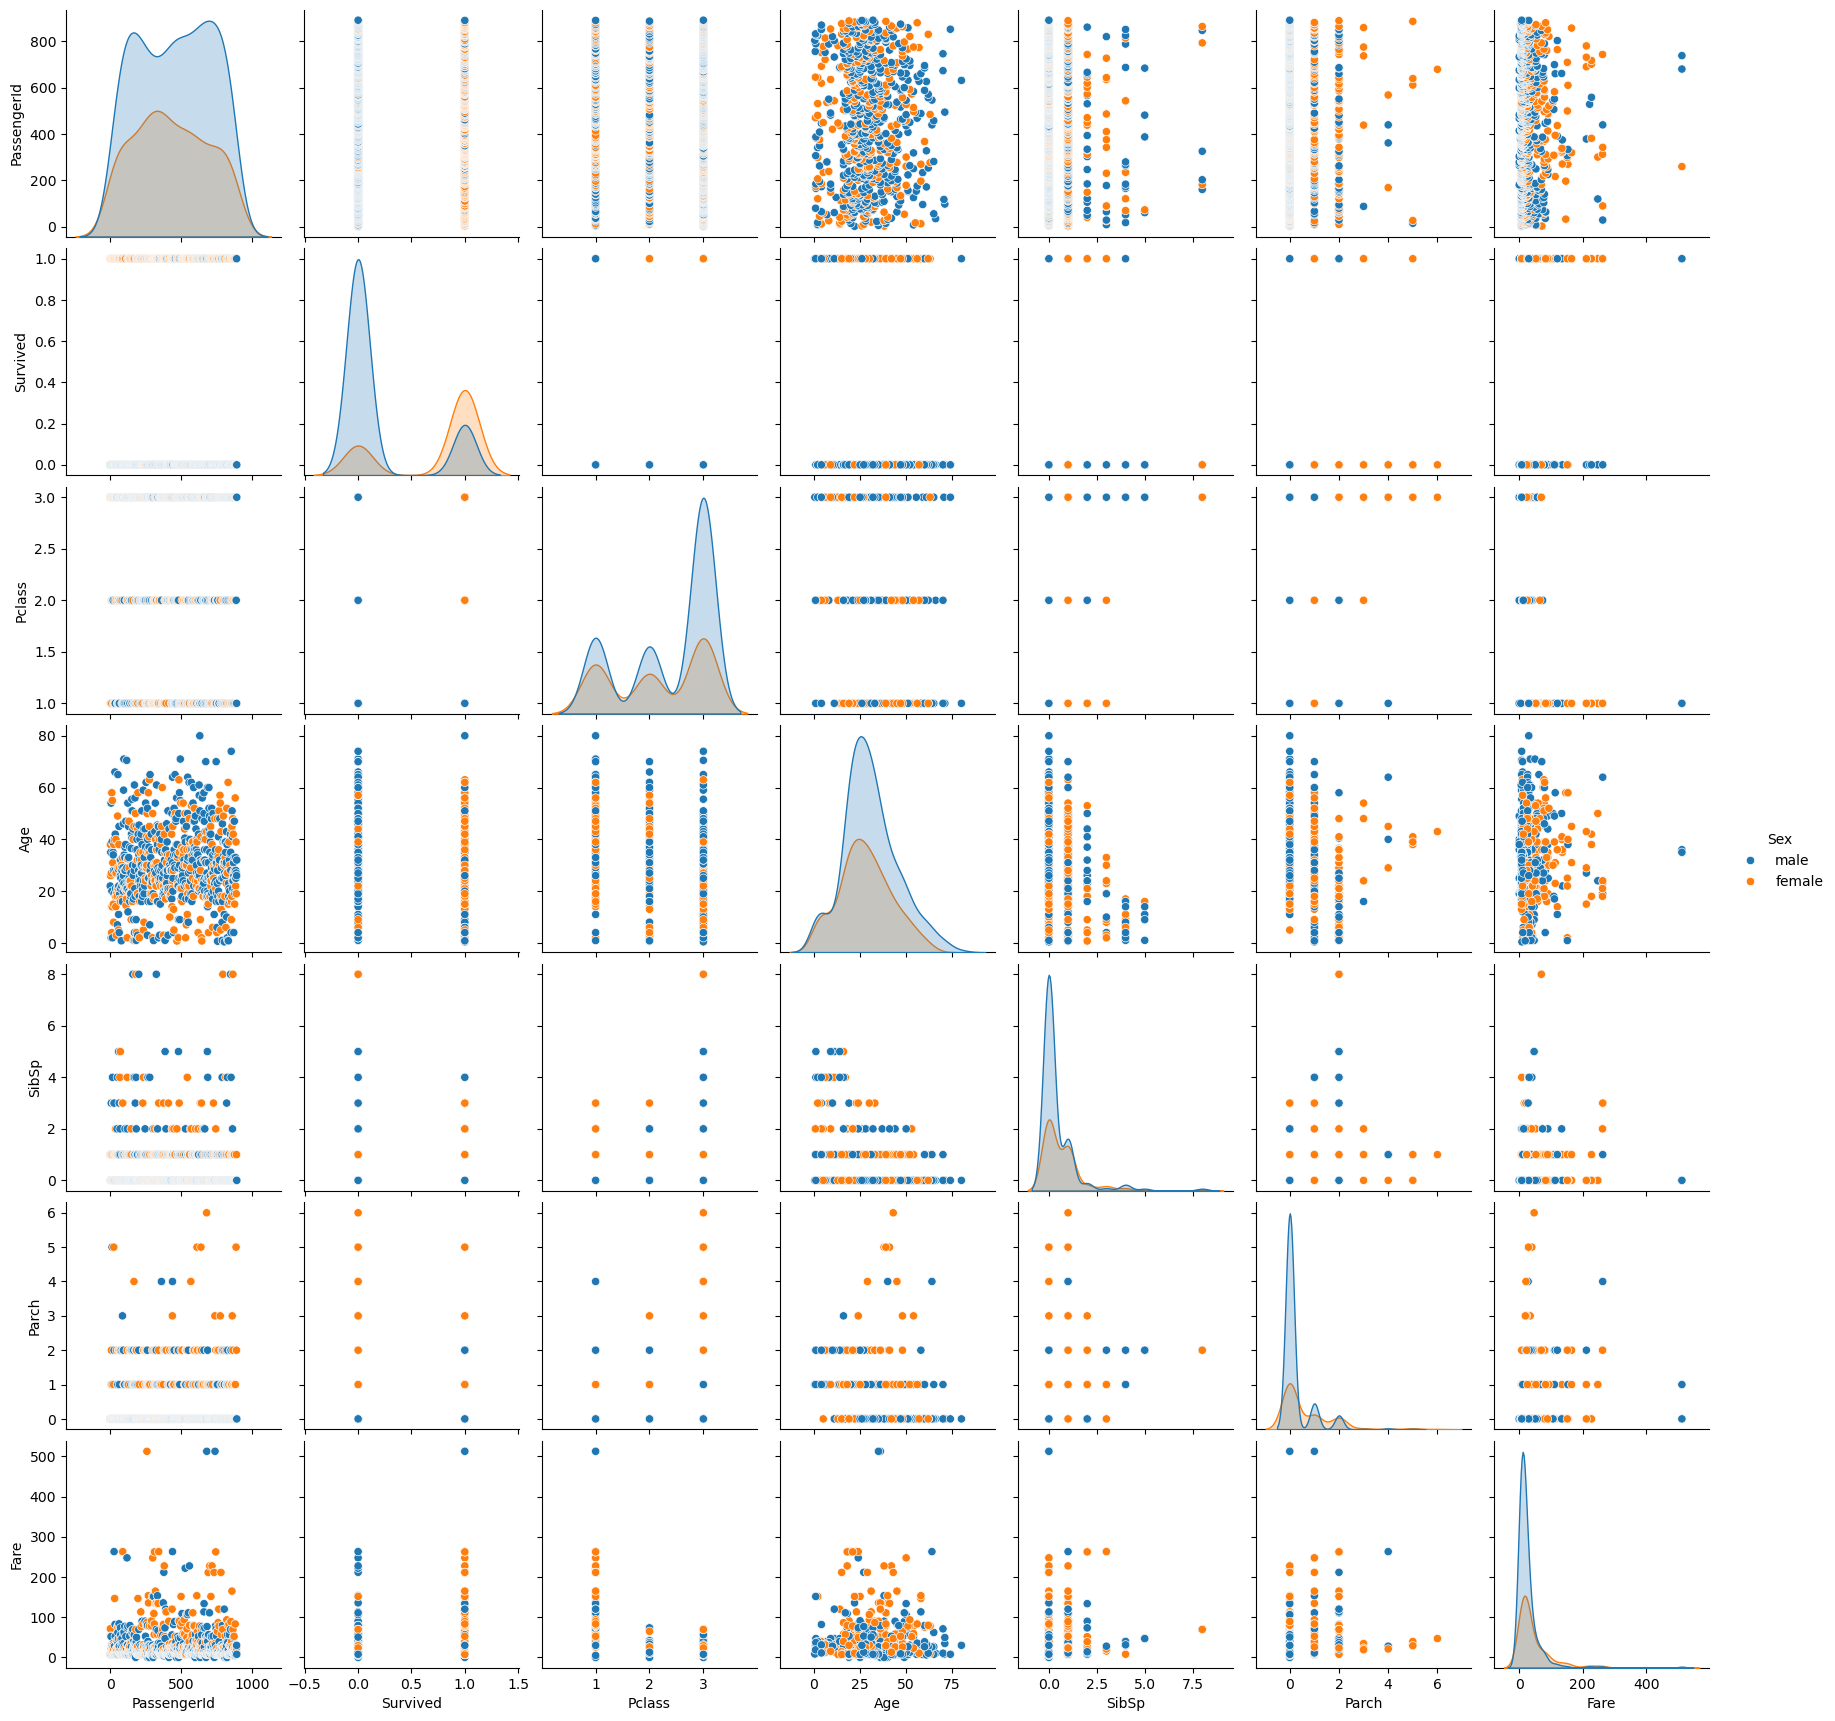

In [238]:
sns.pairplot(df,hue='Sex')

plt.show()

**"The above sex pair plot shows that,Male vs Female comparison of Age, Fare, SibSp, Parch.Females and children had better survival (if Survived included).Fare slightly higher for males in 1st class.**

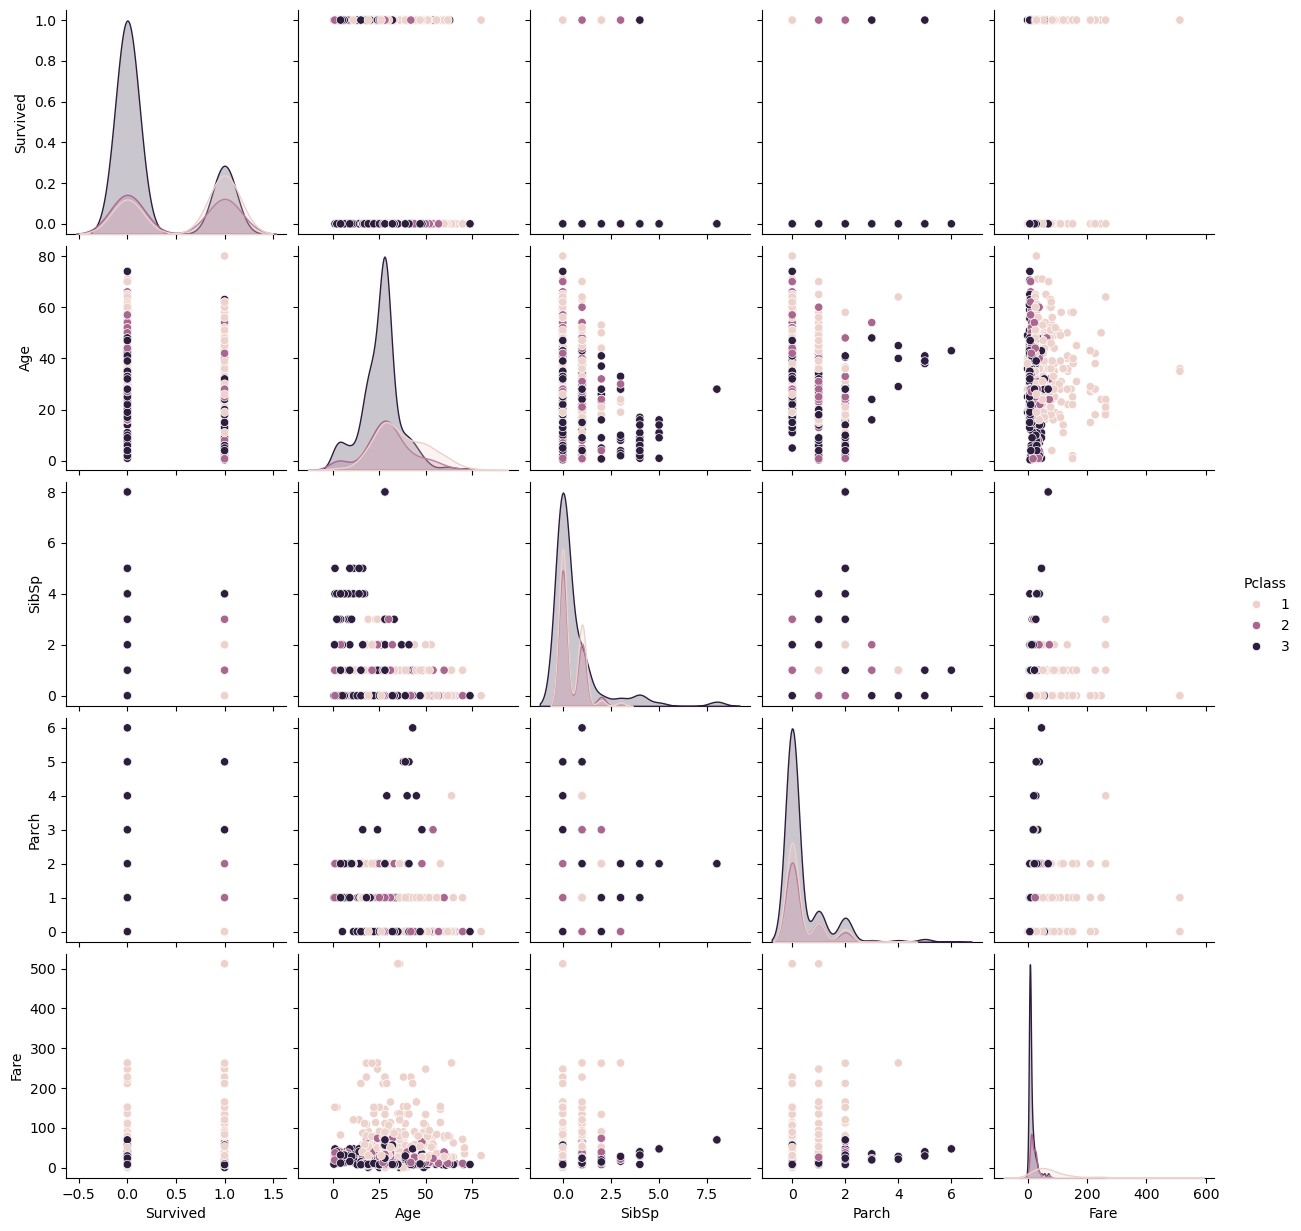

In [27]:
sns.pairplot(df,hue='Pclass')
plt.show()

**"The above passenger class pair plot shows that,1st class = high fare, mostly adults.3rd class = low fare, larger families.Age and fare distribution varies across classes.**

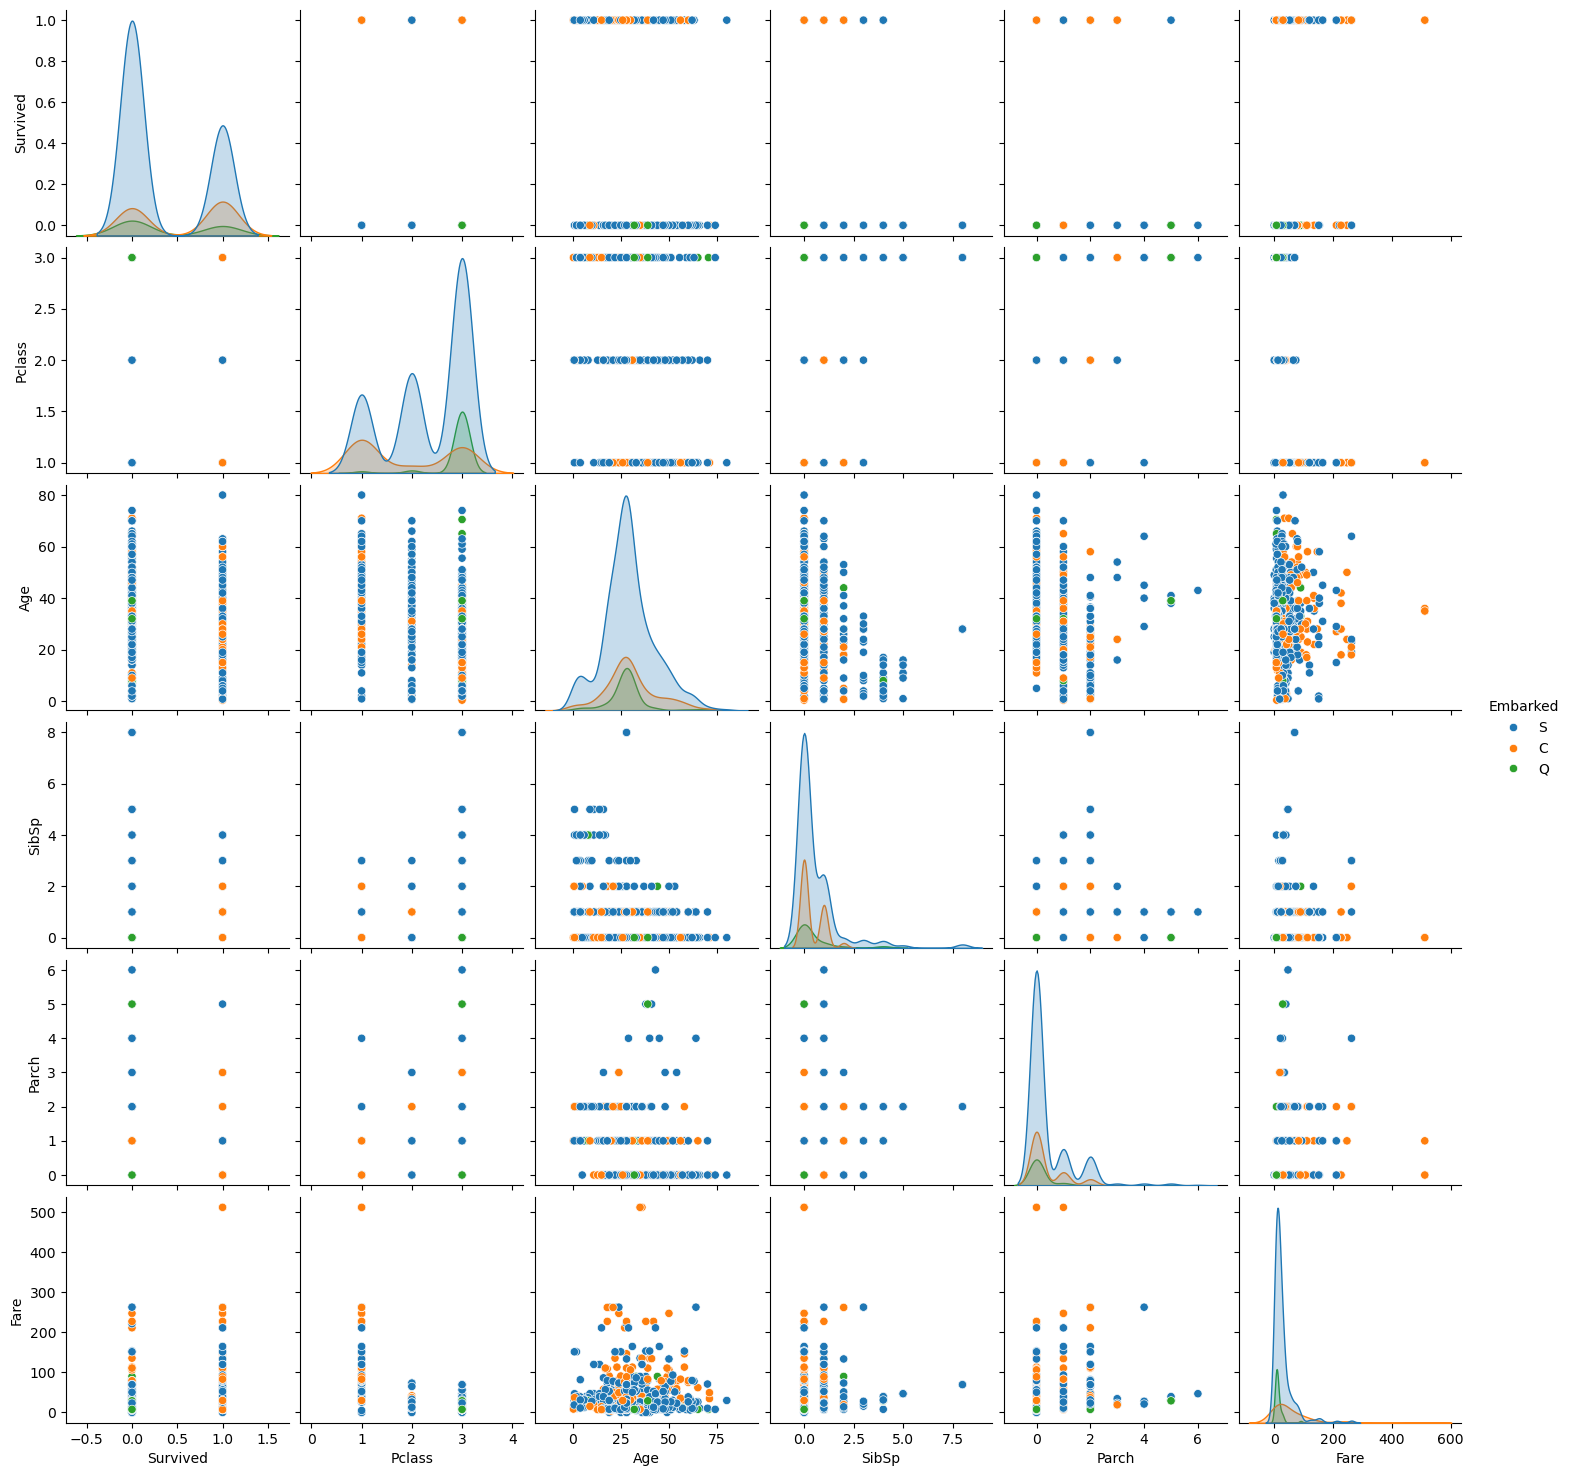

In [28]:
sns.pairplot(df,hue='Embarked')
plt.show()

**"The above Embarked pair plot show that,Colors show different boarding ports: C = Cherbourg.Q = Queenstown, S = Southampton, Fare and Age distribution varies by port.Cherbourg passengers mostly 1st class, higher fare.Southampton passengers mostly 3rd class, lower fare.Small families (SibSp/Parch) common in all ports."**

# **"Feature Engineering"**

In [29]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
df['IsAlone'] = 1
df.loc[df['FamilySize'] > 1, 'IsAlone'] = 0
df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone
0,0,3,male,22.0,1,0,7.2500,S,2,0
1,1,1,female,38.0,1,0,71.2833,C,2,0
2,1,3,female,26.0,0,0,7.9250,S,1,1
3,1,1,female,35.0,1,0,53.1000,S,2,0
4,0,3,male,35.0,0,0,8.0500,S,1,1


**The number of ""siblings/spouses, parents/children"", and the ""passenger"" themselves were combined to produce the new feature "FamilySize".**

**To determine if a traveler was traveling alone or with family, another function called "IsAlone" was developed.**

**This makes it easier for the model to comprehend how family presence affects survival.**

# **"Data Encoding"**

**"Label Encoding"**

In [30]:
Le = LabelEncoder()
df['Sex'] = Le.fit_transform(df['Sex'])
print('\n LEBAL ENCODING (SEX)')
print (df.head())



 LEBAL ENCODING (SEX)
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare Embarked  FamilySize  \
0         0       3    1  22.0      1      0   7.2500        S           2   
1         1       1    0  38.0      1      0  71.2833        C           2   
2         1       3    0  26.0      0      0   7.9250        S           1   
3         1       1    0  35.0      1      0  53.1000        S           2   
4         0       3    1  35.0      0      0   8.0500        S           1   

   IsAlone  
0        0  
1        0  
2        1  
3        0  
4        1  


**"Label Encoding is applied to the 'Sex' column to convert categorical values into numerical form. For example, 'male' is converted to 1 and 'female' to 0. This allows the machine learning model to process gender as a numerical feature."**

**"One Hot Encoding"**

In [31]:
df = pd.get_dummies(df,columns=['Embarked'])
print('\n ONE HOT ENCODING (Embarked)')
print (df.head())


 ONE HOT ENCODING (Embarked)
   Survived  Pclass  Sex   Age  SibSp  Parch     Fare  FamilySize  IsAlone  \
0         0       3    1  22.0      1      0   7.2500           2        0   
1         1       1    0  38.0      1      0  71.2833           2        0   
2         1       3    0  26.0      0      0   7.9250           1        1   
3         1       1    0  35.0      1      0  53.1000           2        0   
4         0       3    1  35.0      0      0   8.0500           1        1   

   Embarked_C  Embarked_Q  Embarked_S  
0       False       False        True  
1        True       False       False  
2       False       False        True  
3       False       False        True  
4       False       False        True  


**"one-Hot Encoding is used to transform the 'Embarked' column into multiple binary columns. Each category (such as S, C, Q) is represented as a separate column with values 0 or 1. This prevents the model from assuming any ordinal relationship between categories."**

# **"Feature Selection"**

In [32]:
X = df.drop('Survived',axis = 1)
y = df['Survived']

**"X = df.drop('Survived', axis=1) selects the features (input data), y = df['Survived'] selects the target variable (output)."**

# **"Standard Scaler"**

In [33]:
standard_scaler =StandardScaler()

standard_scaled= standard_scaler.fit_transform(X[['Age', 'Fare']])
print('STANDARD_SCALER_OUTPUT')
print(pd.DataFrame(standard_scaled, columns=['Age', 'Fare']))

STANDARD_SCALER_OUTPUT
          Age      Fare
0   -0.565736 -0.502445
1    0.663861  0.786845
2   -0.258337 -0.488854
3    0.433312  0.420730
4    0.433312 -0.486337
..        ...       ...
886 -0.181487 -0.386671
887 -0.796286 -0.044381
888 -0.104637 -0.176263
889 -0.258337 -0.044381
890  0.202762 -0.492378

[891 rows x 2 columns]


**"StandardScaler is applied to numerical features like Age and Fare to normalize their values. This ensures that all features are on a similar scale, which helps the Logistic Regression model perform more effectively and improves convergence."**

# **"Splitting the Data"**

In [34]:
X_train, X_test, y_train, y_test = train_test_split(X , y, test_size = 0.2, random_state= 42)
print('TRAINING DATA')
print(X_train)
print('TEST DATA')
print(X_test)

TRAINING DATA
     Pclass  Sex   Age  SibSp  Parch      Fare  FamilySize  IsAlone  \
331       1    1  45.5      0      0   28.5000           1        1   
733       2    1  23.0      0      0   13.0000           1        1   
382       3    1  32.0      0      0    7.9250           1        1   
704       3    1  26.0      1      0    7.8542           2        0   
813       3    0   6.0      4      2   31.2750           7        0   
..      ...  ...   ...    ...    ...       ...         ...      ...   
106       3    0  21.0      0      0    7.6500           1        1   
270       1    1  28.0      0      0   31.0000           1        1   
860       3    1  41.0      2      0   14.1083           3        0   
435       1    0  14.0      1      2  120.0000           4        0   
102       1    1  21.0      0      1   77.2875           2        0   

     Embarked_C  Embarked_Q  Embarked_S  
331       False       False        True  
733       False       False        True  
382    

**"The dataset is divided into training and testing sets using train_test_split. The training data is used to train the model, while the testing data is used to evaluate its performance on unseen data. This helps in checking how well the model generalizes."** 

**"Splitting the data helps prevent overfitting and ensures that the model performs well on new, unseen data."**

# **"Model Building"**  

# **"Logistic Regression"**

In [35]:
model = LogisticRegression()
model.fit(X_train, y_train)

C:\ProgramData\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


**"This code is used to train a Logistic Regression model:"**

**"Imports the Logistic Regression model from scikit-learn."**


**"Creates an instance of the model, ready for training."**


**"Trains the model using the training data (X_train as features and y_train as target) so it can learn patterns and make predictions on new data."**

In [36]:
y_pred = model.predict(X_test)

**"The model has generated predictions for the test dataset. These predictions indicate whether each passenger is classified as survived (1) or not survived (0)."**

**"The output shows how the model is making decisions based on learned patterns."**

# **"Decision Tree Model"**

For classification, the supervised machine learning method Decision Tree is employed. To generate predictions, it divides the data into branches according to feature values.

In [37]:
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


**To identify patterns in the data, the Decision Tree model was trained on the training dataset.**

In [38]:
y_pred_dt = dt_model.predict(X_test)

**Predictions were made on the test dataset using the trained Decision Tree model.**

# **"Model Evaluation"**

# **"Accuracy Scores"**

In [39]:
Lr_acc = accuracy_score(y_test,y_pred)
print('LOGESTIC REGRESSION ACCURACY:',Lr_acc)
print('===========================================================')
dt_acc = accuracy_score(y_test, y_pred_dt)
print('DECISSION TREE ACCURACY:',dt_acc)

LOGESTIC REGRESSION ACCURACY: 0.8044692737430168
DECISSION TREE ACCURACY: 0.770949720670391


**"The accuracy of the Logistic Regression and Decision Tree models was evaluated."**

**Logistic Regression Accuracy is 80%.**  
**Decision Trees Accuracy is 77%.**

**"Based on the comparison of accuracies,it is observed that,Decission Tree may be overfitted that's why it has less accuracy than the Logestic Regression Model.which suggests that logistic regression is better at generalizing to new data.."**

# **"Classification Report"**

In [40]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.82      0.86      0.84       105
           1       0.78      0.73      0.76        74

    accuracy                           0.80       179
   macro avg       0.80      0.79      0.80       179
weighted avg       0.80      0.80      0.80       179



**"The classification report indicates that the model performs better for class 0 (not survived) compared to class 1 (survived)."**

**"The precision for class 0 is (0.82) higher, meaning most passengers predicted as not survived are actually correct. Similarly, recall is (0.86) also strong, showing the model correctly identifies most non-survivors."**

**"However, for class 1, the precision is (0.78) and recall is (0.73) which are comparatively lower, which means the model struggles slightly in correctly predicting passengers who survived."**

**"Overall, the F1-scores show balanced performance, but improvement is needed in predicting survival cases."**

# **"Confusion Matrix"**

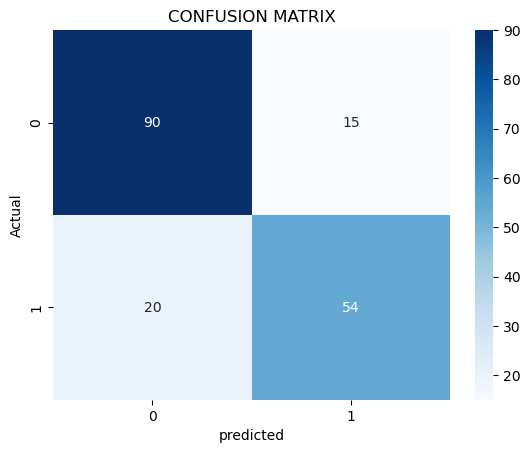

In [41]:
cm = confusion_matrix(y_test,y_pred)
sns.heatmap(cm,annot =True, fmt = 'd',cmap ='Blues')
plt.xlabel('predicted')
plt.ylabel('Actual')
plt.title('CONFUSION MATRIX')
plt.show()

**"The confusion matrix shows that the model correctly predicted 90 passengers as not survived (True Negatives) and 54 passengers as survived (True Positives)."**

**"However, the model incorrectly predicted 15 passengers as survived when they were actually not survived (False Positives), and 20 passengers as not survived when they actually survived (False Negatives)."**

**"This indicates that the model performs well overall, but makes slightly more errors in predicting survival cases compared to non-survival cases."**

## **"Conclusion":**

**This project presents a complete end to end data science pipeline, including data 'preprocessing', 'exploratory data analysis', 'feature engineering', and 'model building'. Various visualizations such as 'gender distribution', 'survival distribution', 'age distribution', and 'survival comparisons' provided meaningful insights into the dataset.**

**The analysis revealed that gender plays a significant role in survival, with female passengers having higher survival rates. Passenger class also influenced outcomes, with higher-class passengers more likely to survive.**  

**Additionally, age-based analysis showed that younger passengers had slightly better survival chances. Passengers traveling with family also demonstrated improved survival compared to those traveling alone.**

**'Feature engineering techniques', including the creation of 'FamilySize', and 'IsAlone', helped enhance the model’s ability to capture important patterns in the data.**

**Two machine learning models, 'Logistic Regression' and 'Decision Tree', were implemented and evaluated using 'accuracy', 'confusion matrix', and 'classification report'. The Logistic Regression model achieved an accuracy of '80%', while the Decision Tree model achieved '77%'. The lower performance of the Decision Tree suggests possible overfitting, whereas Logistic Regression demonstrated better generalization on unseen data.**

**Overall, the Logistic Regression model proved to be more reliable for predicting passenger survival. This project highlights the importance of combining data analysis, visualization, and machine learning techniques to gain insights and solve real world problems.**

### **"Rcommendation:**

**Based on these findings, it is recommended that simpler and well generalized models like Logistic Regression should be preferred for this type of classification problem. Further improvements can be made by tuning model parameters, applying advanced algorithms, and incorporating additional relevant features.**

## **Final Internship Project:**

**Submitted by : Palwasha Mushtaq**  
**Domain : Data Science**  
**Company Name : HexSoftwares**  
**Date : 13th April 2026**